<a href="https://colab.research.google.com/github/Bromine185/NST_exp-/blob/main/02_style_bakeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Style transfer bake-off: Gatys vs AdaIN vs Sliced Wasserstein

Three losses, same content, same style, same optimizer. If VGG features were Gaussian, all three should produce visually similar outputs. If they don't, that's the missing information Gatys is throwing away.

- **Gatys**: matches Gram matrices (uncentered 2nd moment of feature vectors).
- **AdaIN loss**: matches per-channel mean + std (1st + 2nd marginal moments).
- **Sliced Wasserstein**: matches the full joint feature distribution via random 1D projections. Sorted-MSE on a 1D projection is exactly 1D W2². Averaging over projections converges to true multivariate W2².

**Setup**: Runtime → Change runtime type → GPU. Upload `content.jpg` and `style.jpg`, or use the wget cell.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
torch.manual_seed(42); np.random.seed(42)

device: cuda


In [2]:
import os
import shutil

# Style image
if os.path.exists('/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'):
    shutil.copy('/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg',
                '/content/style.jpg')
else:
    !wget -q -O /content/style.jpg \
      https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1024px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg

# Content image
if os.path.exists('/content/lavender-field-sunset-near-valensole_268835-3910.avif'):
    shutil.copy('/content/lavender-field-sunset-near-valensole_268835-3910.avif',
                '/content/content.jpg')
else:
    !wget -q -O /content/content.jpg \
      https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/560px-PNG_transparency_demonstration_1.png

print('files ready')

files ready


In [3]:
# --- VGG feature extractor ---
class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = tvm.vgg19(weights=tvm.VGG19_Weights.IMAGENET1K_V1).features.eval()
        self.layer_ids = {'relu1_1': 1, 'relu2_1': 6, 'relu3_1': 11,
                          'relu4_1': 20, 'relu5_1': 29}
        self.vgg = vgg
        for p in self.parameters(): p.requires_grad_(False)

    def forward(self, x):
        feats, last = {}, max(self.layer_ids.values())
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            for name, idx in self.layer_ids.items():
                if i == idx: feats[name] = x
            if i >= last: break
        return feats

# --- image I/O ---
IMG_SIZE = 384   # bump to 512 if you have time / a fatter GPU

def load_image(path):
    tf = T.Compose([T.Resize(IMG_SIZE), T.CenterCrop(IMG_SIZE), T.ToTensor(),
                    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    return tf(Image.open(path).convert('RGB')).unsqueeze(0).to(device)

def denorm(x):
    m = torch.tensor([0.485,0.456,0.406], device=x.device).view(1,3,1,1)
    s = torch.tensor([0.229,0.224,0.225], device=x.device).view(1,3,1,1)
    return (x*s + m).clamp(0,1)

vgg = VGGFeatures().to(device)
content = load_image('content.jpg')
style = load_image('style.jpg')
print('content', content.shape, 'style', style.shape)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 232MB/s]


content torch.Size([1, 3, 384, 384]) style torch.Size([1, 3, 384, 384])


## The three style losses

In [4]:
def gram(f):
    B, C, H, W = f.shape
    F_ = f.reshape(B, C, H*W)
    return (F_ @ F_.transpose(1,2)) / (C*H*W)

def gatys_loss(gen, sty):
    return sum(F.mse_loss(gram(gen[l]), gram(sty[l])) for l in sty)

def adain_loss(gen, sty):
    total = 0
    for l in sty:
        g, s = gen[l], sty[l]
        total = total + F.mse_loss(g.mean([2,3]), s.mean([2,3])) \
                     + F.mse_loss(g.std([2,3]),  s.std([2,3]))
    return total

def sliced_wasserstein_loss(gen, sty, n_proj=64):
    """Heitz et al. 2021. Sorted-MSE on random 1D projections == 1D W2²."""
    total = 0
    for l in sty:
        g, s = gen[l], sty[l]
        C = g.shape[1]
        g_flat = g.reshape(C, -1).T        # [HW, C] point cloud in R^C
        s_flat = s.reshape(C, -1).T
        V = torch.randn(C, n_proj, device=g.device)
        V = V / V.norm(dim=0, keepdim=True)
        gp, sp = g_flat @ V, s_flat @ V    # [HW, n_proj]
        gs, _ = gp.sort(dim=0)
        ss, _ = sp.sort(dim=0)
        total = total + F.mse_loss(gs, ss)
    return total

In [10]:
def sliced_wasserstein_loss(gen, sty, n_proj=64):
    total = 0.0
    for i, l in enumerate(sty):
        g, s = gen[l], sty[l]
        C = g.shape[1]
        g_flat = g.reshape(C, -1).T
        s_flat = s.reshape(C, -1).T

        # Use a deterministic generator for L-BFGS line search to work
        gen_rng = torch.Generator(device=g.device)
        gen_rng.manual_seed(42 + i)
        V = torch.randn(C, n_proj, generator=gen_rng, device=g.device)

        V = V / (V.norm(dim=0, keepdim=True) + 1e-8)
        gp, sp = g_flat @ V, s_flat @ V
        gs, _ = gp.sort(dim=0)
        ss, _ = sp.sort(dim=0)
        loss = F.mse_loss(gs, ss)
        if torch.isnan(loss) or torch.isinf(loss):
            print("SW NaN/inf at layer", l)
        total = total + loss
    return total


## Optimizer

Standard Gatys setup: initialize the generated image to the content, LBFGS on pixels, content loss at `relu4_1`, style loss whichever we pass in. Style weights differ per method because loss magnitudes differ — Gram is a `C×C` squared quantity, AdaIN is a `C`-vector, SW is per-projection MSE.

In [11]:
def stylize(content, style, vgg, loss_fn, style_w, content_w=1.0,
            content_layer='relu4_1', n_iter=250, tag=''):
    gen = content.clone().requires_grad_(True)
    sty_feats = {k: v.detach() for k, v in vgg(style).items()}
    con_feats = {k: v.detach() for k, v in vgg(content).items()}
    opt = torch.optim.LBFGS([gen], lr=1.0, max_iter=n_iter,
                             line_search_fn='strong_wolfe')
    step = [0]
    def closure():
        opt.zero_grad()
        gf = vgg(gen)
        sL = loss_fn(gf, sty_feats)
        cL = F.mse_loss(gf[content_layer], con_feats[content_layer])
        L = style_w * sL + content_w * cL
        L.backward()
        step[0] += 1
        if step[0] % 40 == 0:
            print(f'  [{tag}] step {step[0]:4d}  style={sL.item():.3e}  content={cL.item():.3e}')
        return L
    opt.step(closure)
    return gen.detach()

In [7]:
print('--- Gatys (Gram) ---')
out_gatys = stylize(content, style, vgg, gatys_loss, style_w=1e6, tag='gatys')
print('--- AdaIN loss ---')
out_adain = stylize(content, style, vgg, adain_loss,  style_w=1e2, tag='adain')


--- Gatys (Gram) ---
  [gatys] step   40  style=4.513e-06  content=5.649e+00
  [gatys] step   80  style=2.310e-06  content=4.695e+00
  [gatys] step  120  style=2.049e-06  content=4.415e+00
  [gatys] step  160  style=1.951e-06  content=4.284e+00
  [gatys] step  200  style=1.885e-06  content=4.225e+00
  [gatys] step  240  style=1.855e-06  content=4.173e+00
--- AdaIN loss ---
  [adain] step   40  style=1.672e-01  content=9.537e+00
  [adain] step   80  style=5.913e-02  content=8.435e+00
  [adain] step  120  style=2.257e-02  content=7.701e+00
  [adain] step  160  style=1.083e-02  content=7.200e+00
  [adain] step  200  style=7.452e-03  content=6.845e+00
  [adain] step  240  style=5.493e-03  content=6.646e+00


In [12]:
print('--- Sliced Wasserstein ---')
out_sw = stylize(
    content, style, vgg,
    lambda g, s: sliced_wasserstein_loss(g, s, n_proj=16),
    style_w=1e3, tag='sw'
)

--- Sliced Wasserstein ---
  [sw] step   40  style=8.679e-02  content=8.066e+00
  [sw] step   80  style=4.076e-02  content=7.582e+00
  [sw] step  120  style=3.019e-02  content=7.189e+00
  [sw] step  160  style=2.357e-02  content=6.763e+00
  [sw] step  200  style=1.767e-02  content=6.468e+00
  [sw] step  240  style=1.259e-02  content=6.256e+00


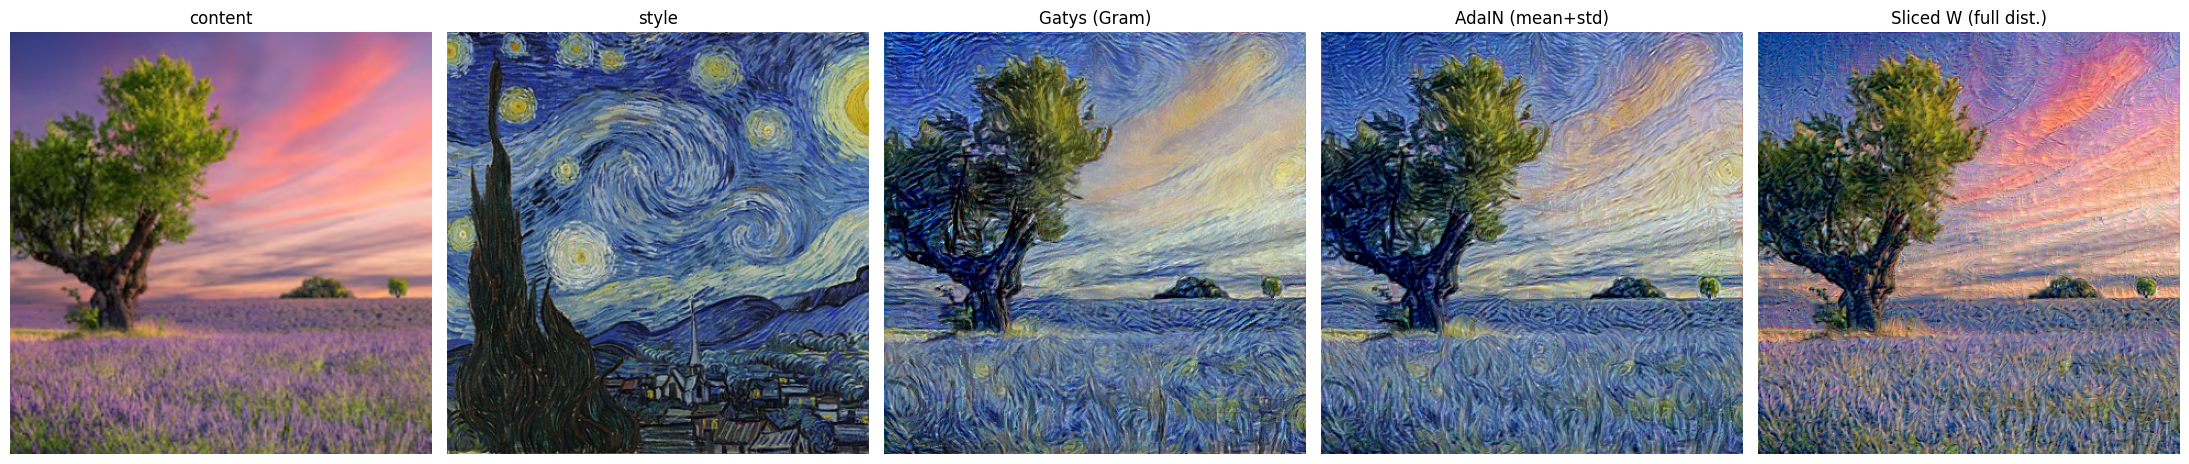

In [13]:
fig, ax = plt.subplots(1, 5, figsize=(22, 5))
for a, im, t in zip(ax,
                    [content, style, out_gatys, out_adain, out_sw],
                    ['content', 'style',
                     'Gatys (Gram)', 'AdaIN (mean+std)',
                     'Sliced W (full dist.)']):
    a.imshow(denorm(im).squeeze().permute(1,2,0).cpu().numpy())
    a.set_title(t); a.axis('off')
plt.tight_layout()
plt.savefig('style_bakeoff.png', dpi=120)
plt.show()

## Reading the result

- If Gatys and AdaIN look similar and SW looks different, that difference is exactly the higher-moment information Gatys throws away. Textures with strong non-Gaussian structure (brushstrokes, edges, granular patterns) should show it most.
- If all three look basically the same, the Gaussian approximation is fine for this style pair — style pair matters. Try a highly textured style (Van Gogh, mosaic, etching) vs a smooth one (Rothko) and compare.

**Weight tuning tips**: if content shows through too much bump `style_w` by 10×. If the image goes to noise/mush, drop it by 10×. Every loss has its own scale.

Notebook 03 does the deeper quantitative comparison — measures how much distributional mismatch each method leaves behind.